In [1]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
np.random.seed(30)     # Setting random seed for reproducibility
# X=np.random.randint(100,size=(100,2))
X = np.random.normal(loc=50, scale=15, size=(100,2))
# Normal distribution for natural-looking data
X[99] = [5, 180]      # Converting program in anomaly (outlier) detection
X[98] = [12, 170]
print(X)

[[ 31.03921003  72.91858027]
 [ 35.43933593  57.05839424]
 [ 48.48954925  54.55689777]
 [ 24.11056357  73.77643054]
 [ 52.0144489   33.397168  ]
 [ 73.67338324  51.61246914]
 [ 38.5392826   38.37217236]
 [ 70.75770748  61.40577627]
 [ 45.71531729  58.07551215]
 [ 18.74155052  64.06672565]
 [ 49.91333006  42.98781549]
 [ 43.65477051  65.9672314 ]
 [  6.44948605  74.25335562]
 [ 71.38264829  40.02867322]
 [ 64.77526789  24.49302102]
 [ 33.49784289  30.26533864]
 [ 62.15751365  34.32832439]
 [ 39.6615594   37.20864703]
 [ 66.70208161  21.18245423]
 [ 39.47896373  62.73631774]
 [ 65.76049682  41.94688317]
 [ 49.56210923  70.91083977]
 [ 44.03198837  65.28691077]
 [ 78.4832195   44.67725534]
 [ 44.19475294  21.09041922]
 [ 58.26134889  64.31533719]
 [ 61.74164756  23.10143147]
 [ 68.62783245  75.61620314]
 [ 54.84730095  35.12248409]
 [ 32.55076441  49.67997351]
 [ 26.27007062  31.35328723]
 [ 43.84746464  34.17386993]
 [ 34.14031786  30.73824176]
 [ 63.69689061  29.18381989]
 [ 50.45041645

In [6]:
# Converting program in anomaly detection
# X[99]=[8,150]
# X[98]=[10,160]
# print(X)

In [36]:
# kmeans = KMeans(n_clusters = 5, init = 'k-means++', 
#          max_iter = 300, n_init = 10, random_state = 0)
kmeans = KMeans(n_clusters=5, init='k-means++', 
                max_iter=250, n_init=15, random_state=0)
y_kmeans = kmeans.fit_predict(X)

In [37]:
print(y_kmeans)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 4 4 4 2 4 4 4 2 4 2 2 4 2 4 2 4 4 2 4 2 4 2 4 4
 4 4 4 4 4 2 2 2 2 4 2 4 4 4 2 2 2 4 2 2 2 2 2 4 2 2 3 4 0 3 3 0 2 0 3 0 3
 3 3 4 3 3 3 0 0 4 3 4 0 4 3 0 4 4 3 0 0 0 3 4 4 0 3 3 4 3 3 3 4 3 3 3 4 3
 3 4]


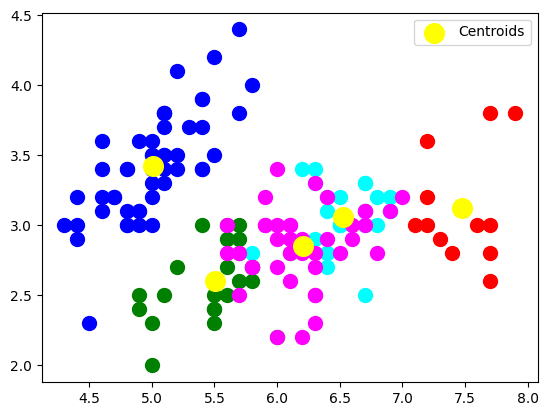

In [38]:
#Visualising the clusters
# plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red')
# plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue')
# plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green')
# plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan')
# plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta')

# Alternate way (automatically choose colors instead of manual)
colors = ['red','blue','green','cyan','magenta']
for i in range(kmeans.n_clusters):
  plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=100, c=colors[i])
#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], 
            s = 200, c = 'yellow', label = 'Centroids')
plt.legend()

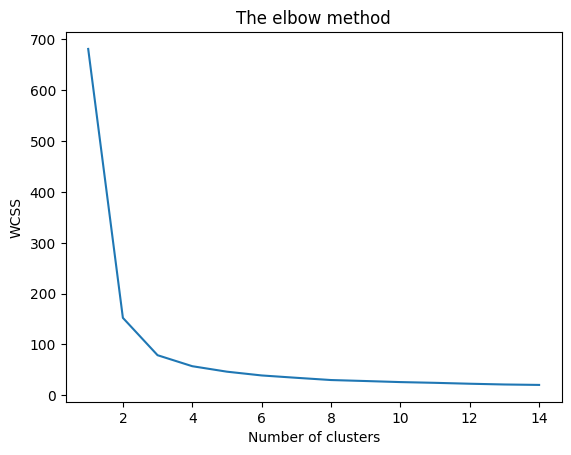

In [39]:
# Elbow Method for finding optimal clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', 
                    max_iter = 250, n_init = 15, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

#Plotting the results onto a line graph, allowing us to observe 'The elbow'
plt.plot(range(1, 15), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

In [40]:
from sklearn.metrics import silhouette_score
SS=[]
# kmeans = KMeans(n_clusters = 5, init = 'k-means++', 
#              max_iter = 300, n_init = 10, random_state = 0)
kmeans = KMeans(n_clusters = 5, init = 'k-means++', 
                max_iter = 250, n_init = 15, random_state = 0)
kmeans.fit(X)
labels = kmeans.labels_
SS=silhouette_score(X,labels,metric='euclidean')
print(SS)
print(labels)

0.48874888709310566
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 4 4 4 2 4 4 4 2 4 2 2 4 2 4 2 4 4 2 4 2 4 2 4 4
 4 4 4 4 4 2 2 2 2 4 2 4 4 4 2 2 2 4 2 2 2 2 2 4 2 2 3 4 0 3 3 0 2 0 3 0 3
 3 3 4 3 3 3 0 0 4 3 4 0 4 3 0 4 4 3 0 0 0 3 4 4 0 3 3 4 3 3 3 4 3 3 3 4 3
 3 4]


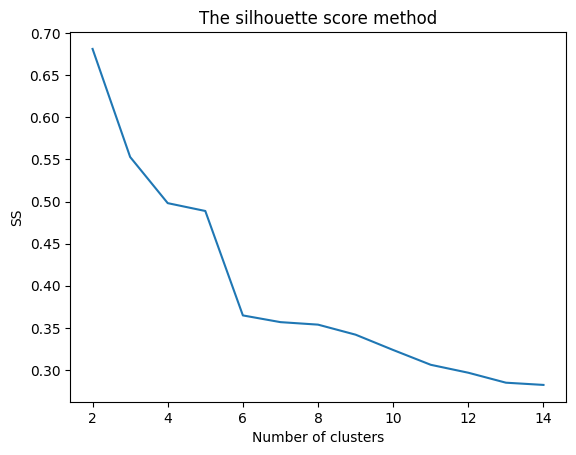

In [41]:
from sklearn.metrics import silhouette_score
SS=[]
for i in range(2,15):
    # kmeans = KMeans(n_clusters = i, init = 'k-means++', 
    # max_iter = 300, n_init = 10, random_state = 0)
    kmeans = KMeans(n_clusters = i, init = 'k-means++', 
                    max_iter = 250, n_init = 15, random_state = 0)
    kmeans.fit(X)
    labels = kmeans.labels_
    ss=silhouette_score(X,labels, metric='euclidean')
    SS.append(ss)

#Plotting the results onto a line graph, allowing to observe'The elbow'
plt.plot(range(2, 15),SS)
plt.title('The silhouette score method')
plt.xlabel('Number of clusters')
plt.ylabel('SS') #within cluster sum of squares
plt.show()

**Iris Flower Clustering using K Means**

In [42]:
iris = load_iris()
X = iris.data
y = iris.target

In [43]:
# kmeans = KMeans(n_clusters = 3, init = 'k-means++', 
#           max_iter = 300, n_init = 10, random_state = 0)
kmeans = KMeans(n_clusters = 3, init = 'k-means++', 
                max_iter = 250, n_init = 15, random_state = 0)
y_kmeans = kmeans.fit_predict(X)

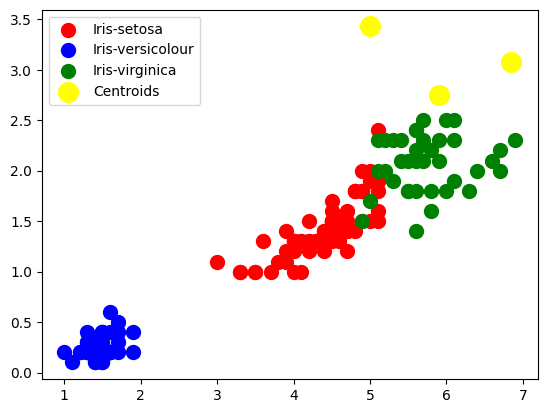

In [47]:
#Visualising the clusters
# plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Iris-setosa')
# plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Iris-versicolour')
# plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')
# Alternate used different feature pair (like petal length vs petal width 
#                instead of sepal length vs sepal width)
plt.scatter(X[y_kmeans == 0, 2], X[y_kmeans == 0, 3], 
            s = 100, c = 'red', label = 'Iris-setosa')
plt.scatter(X[y_kmeans == 1, 2], X[y_kmeans == 1, 3], 
            s = 100, c = 'blue', label = 'Iris-versicolour')
plt.scatter(X[y_kmeans == 2, 2], X[y_kmeans == 2, 3], 
            s = 100, c = 'green', label = 'Iris-virginica')
#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], 
            s = 200, c = 'yellow', label = 'Centroids')
plt.legend()